<a href="https://colab.research.google.com/github/navsingh2024-bit/Gen_AI-Property_price_prediction-/blob/main/Gen_AI_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏡 Project 9: Intelligent Property Price Prediction
**Milestone 1: Classical Machine Learning on Gurgaon Real Estate**

**Objective:**
Develop an end-to-end machine learning pipeline to predict real estate prices based on proprietary property attributes (BHK, Luxury Category, Sector Location).

**Technical Stack Compliance:**
* **Dataset:** Custom Gurgaon Properties (Post-Feature Selection)
* **Algorithm:** Random Forest Regressor
* **Workflow:** Scikit-Learn Pipelines (StandardScaler + OneHotEncoder)
* **Evaluation:** R-Squared ($R^2$), Mean Absolute Error (MAE)


In [ ]:
# Phase 1: Environment Setup & Data Ingestion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-Learn Modules (Rubric Required)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# Load the proprietary dataset
df = pd.read_csv('gurgaon_properties_post_feature_selection_v2.csv')

print("--- Data Ingestion Complete ---")
print(f"Total Properties: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

--- Data Ingestion Complete ---
Total Properties: 3554
Total Features: 13


### Phase 2: Exploratory Data Analysis (EDA)
Establishing the statistical baseline required for the Mid-Sem Project Report. Note: Categorical features are excluded from the correlation heatmap to maintain matrix integrity.

--- Summary Statistics ---


,price,bedRoom,bathroom,built_up_area,servant room,store room,furnishing_type
count,3554.000000,3554.000000,3554.000000,3554.000000,3554.000000,3554.000000,3554.000000
mean,2.441533,3.092572,3.267586,1861.515790,0.358751,0.090321,0.391671
std,2.783788,1.245600,1.450033,1216.429665,0.479701,0.286681,0.586170
min,0.070000,1.000000,1.000000,33.000000,0.000000,0.000000,0.000000
25%,0.950000,2.000000,2.000000,1202.500000,0.000000,0.000000,0.000000
50%,1.510000,3.000000,3.000000,1614.000000,0.000000,0.000000,0.000000
75%,2.650000,4.000000,4.000000,2200.000000,1.000000,0.000000,1.000000
max,31.500000,10.000000,12.000000,12222.000000,1.000000,1.000000,2.000000


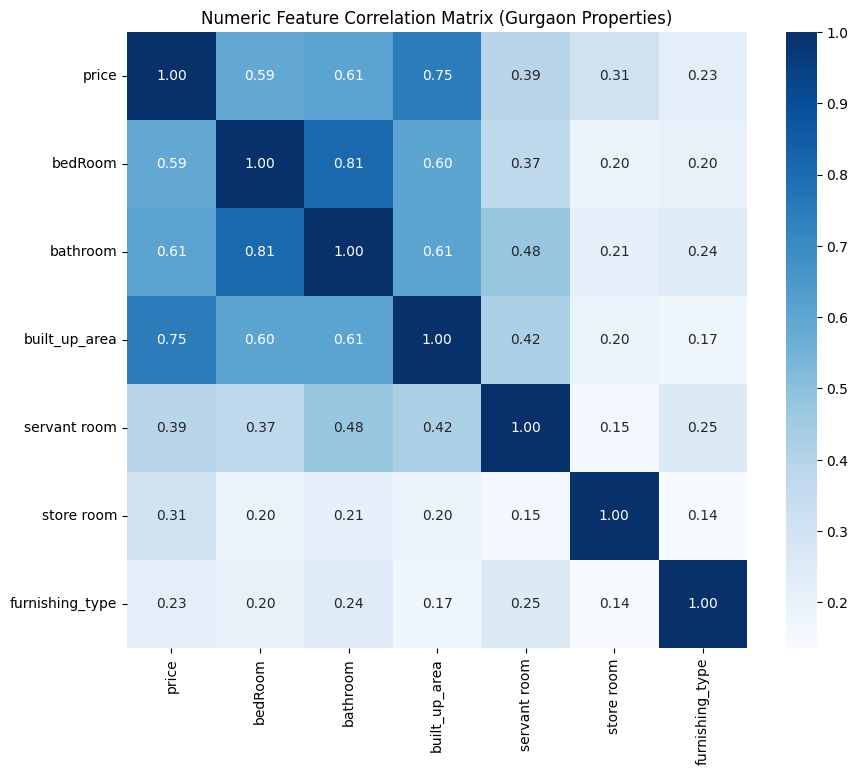

In [ ]:
# 1. Statistical Summary (Copy this for your "Data Description" report section)
print("--- Summary Statistics ---")
display(df.describe())

# 2. Identify Numeric Columns for Correlation
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# 3. Feature Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues', fmt=".2f", annot_kws={"size": 10})
plt.title("Numeric Feature Correlation Matrix (Gurgaon Properties)")
plt.show()

### Phase 3: Model Architecture & Scikit-Learn Pipeline
To handle a mix of categorical (e.g., Sector, Property Type) and numerical data without data leakage, we utilize a `ColumnTransformer` inside the `Pipeline`.
1. **Numeric Features**: Scaled using `StandardScaler`.
2. **Categorical Features**: Encoded using `OneHotEncoder`.
3. **Model**: `RandomForestRegressor` (Hyperparameters constrained to ensure deployment file size remains < 100MB).

In [ ]:
# 1. Separate Features (X) and Target (y)
X = df.drop(columns=['price'])
y = df['price']

# 2. Dynamically identify categorical vs numerical columns
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 3. Build the Preprocessing Engine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 4. Construct the Final Pipeline (Fulfills Rubric Requirement)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf_model', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1 # Uses all cores for fast training
    ))
])

# 5. Train/Test Split & Execution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Initiating Pipeline Training on Gurgaon Dataset...")
pipeline.fit(X_train, y_train)
print("Model Training Complete.")

Initiating Pipeline Training on Gurgaon Dataset...
Model Training Complete.


### Phase 4: Model Evaluation
Testing the predictive accuracy on the unseen 20% validation set using standard regression metrics.

--- Model Performance on Test Set (Copy to Report) ---
R-Squared (Variance Explained): 0.8147
Mean Absolute Error (MAE):      0.5754
Root Mean Squared Error (RMSE): 1.1934


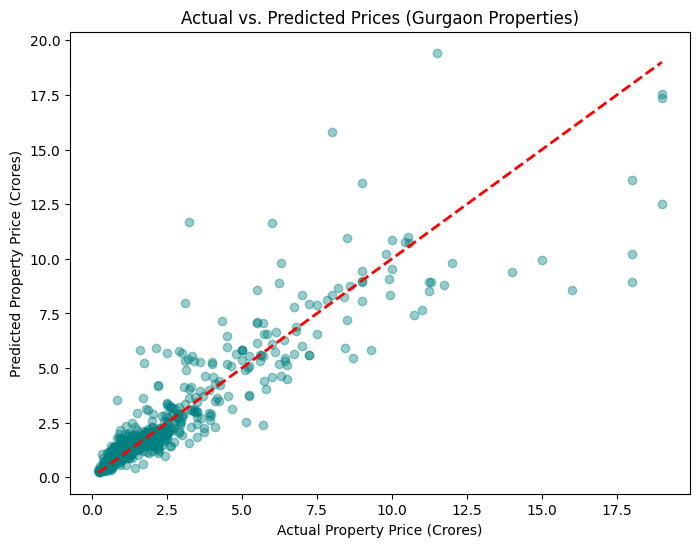

In [ ]:
# Generate predictions on unseen test data
y_pred = pipeline.predict(X_test)

# Calculate Core Metrics
r2 = metrics.r2_score(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

print('--- Model Performance on Test Set (Copy to Report) ---')
print(f'R-Squared (Variance Explained): {r2:.4f}')
print(f'Mean Absolute Error (MAE):      {mae:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

# Visualizing Actual vs. Predicted Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Property Price (Crores)")
plt.ylabel("Predicted Property Price (Crores)")
plt.title("Actual vs. Predicted Prices (Gurgaon Properties)")
plt.show()

### Phase 5: Serialization & Deployment Prep
Serializing the trained pipeline utilizing compression. This ensures the `.pkl` artifact complies with GitHub's strict 100MB repository limits for Milestone 2 deployment.

In [ ]:
# Save the model for UI integration
model_filename = 'rf_gurgaon_pipeline.pkl'
joblib.dump(pipeline, model_filename, compress=3)

print(f"Pipeline successfully serialized and saved as '{model_filename}'")
print("Ready for Streamlit UI integration.")

Pipeline successfully serialized and saved as 'rf_gurgaon_pipeline.pkl'
Ready for Streamlit UI integration.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# 1. Load the pristine dataset
df = pd.read_csv('gurgaon_properties_post_feature_selection_v2.csv')

# 2. Separate target (price) and features
X = df.drop(columns=['price'])
y = df['price']

# 3. Dynamically group numerical and categorical columns for the Pipeline
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 4. Create the Preprocessing Engine (Crucial for the Viva Voce)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 5. Build the Final Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf_model', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

# 6. Split Data & Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Random Forest Pipeline on Gurgaon Data...")
pipeline.fit(X_train, y_train)

# 7. Evaluate Model Accuracy
y_pred = pipeline.predict(X_test)
r2 = metrics.r2_score(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)

print('\n--- Model Performance ---')
print(f'R-Squared (Variance Explained): {r2:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f} Crores')

# 8. Compress and Save for UI Deployment
joblib.dump(pipeline, 'rf_gurgaon_pipeline1.pkl', compress=3)
print("\nModel saved as 'rf_gurgaon_pipeline1.pkl'")

Training Random Forest Pipeline on Gurgaon Data...

--- Model Performance ---
R-Squared (Variance Explained): 0.8147
Mean Absolute Error (MAE): 0.5754 Crores

Model saved as 'rf_gurgaon_pipeline1.pkl'
